Preprocessing the movement for modeling

In [1]:
#Importing dependencies
import pandas as pd
import os

In [4]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Acccelometer_Gyrometer/preprocessed/file_list.csv")

In [5]:
df

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor,label
0,patient,1,PADS,Healthy,-,56,56,173,78,male,right,True,True,Unknown,0
1,patient,2,PADS,Other Movement Disorders,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect,2
2,patient,3,PADS,Healthy,-,45,45,170,78,female,right,False,NaN,Unknown,0
3,patient,4,PADS,Parkinson's,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect,1
4,patient,5,PADS,Parkinson's,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,patient,465,PADS,Parkinson's,IPS mixed type,62,65,175,80,male,right,True,False,No effect,1
465,patient,466,PADS,Healthy,-,84,84,172,74,female,right,True,True,No effect,0
466,patient,467,PADS,Parkinson's,"Essential Tremor, starting IPS tremordominant ...",55,57,190,100,male,right,False,NaN,Improvement,1
467,patient,468,PADS,Parkinson's,IPS mixed type,73,76,198,118,male,right,False,NaN,No effect,1


In [6]:
print(df["condition"].value_counts())

condition
Parkinson's                 276
Healthy                      79
Other Movement Disorders     60
Essential Tremor             28
Atypical Parkinsonism        15
Multiple Sclerosis           11
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

resource_type                          0
id                                     0
study_id                               0
condition                              0
disease_comment                        0
age_at_diagnosis                       0
age                                    0
height                                 0
weight                                 0
gender                                 0
handedness                             0
appearance_in_kinship                  0
appearance_in_first_grade_kinship    288
effect_of_alcohol_on_tremor            0
label                                  0
dtype: int64


In [10]:

# Define column names for timeseries data as per what the paper suggested 
columns = ['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z', 
           'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']

def extract_features(df):
    features = {}
    sensor_cols = columns[1:]  # exclude Time column
    
    #For each column present, calculate descriptiv4 stats to reduce dimensioinality of data 
    for col in sensor_cols:
        features[f'{col}_mean'] = df[col].mean()
        features[f'{col}_std'] = df[col].std()
        features[f'{col}_max'] = df[col].max()
        features[f'{col}_min'] = df[col].min()
    
    #Return key value pairs of the feature
    return features

def load_and_extract_all(timeseries_folder):
    all_features = []
    
    #looping through each filename in the timeseries,
    for filename in os.listdir(timeseries_folder):
        if filename.endswith('.txt'):
            #looking for files wityh the timer series folder and join them together 
            filepath = os.path.join(timeseries_folder, filename)
            # Load with proper column names
            df = pd.read_csv(filepath, names=columns, sep=',')
            
            feats = extract_features(df)
            
            # Extract metadata from filename, with the format ("001_Task_LeftWrist.txt")
            #sp[lit returns a list split by _
            parts = filename.split('_')
            #parse out patient id
            patient_id = parts[0]
            #get the task name
            task = parts[1] if len(parts) > 1 else 'unknown'
            #get the wrist id as well
            wrist = parts[2].replace('.txt','') if len(parts) > 2 else 'unknown'
            #Append to the dictionary all the indices
            feats['patient_id'] = patient_id
            feats['task'] = task
            feats['wrist'] = wrist
            #Append to the list thje dictionary 
            all_features.append(feats)
    
    #return pd dataframe
    return pd.DataFrame(all_features)

#Call the funcsions and link the path to folder and load it
timeseries_folder = "/users/imbahndu/Desktop/Columbia DBM/Acccelometer_Gyrometer/movement/timeseries"
features_df = load_and_extract_all(timeseries_folder)



In [11]:
features_df

,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,Accelerometer_Z_mean,Accelerometer_Z_std,...,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,patient_id,task,wrist
0,-0.130550,0.248221,0.032630,-1.045084,-0.044359,0.222880,0.597029,-0.955157,0.049997,0.177653,...,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,001,CrossArms,LeftWrist
1,-0.096928,0.185871,0.075998,-0.702096,0.040016,0.192354,0.763317,-0.601505,0.064342,0.176071,...,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,001,CrossArms,RightWrist
2,-0.006727,0.066519,0.545251,-0.220897,-0.004940,0.121849,0.956026,-1.207944,0.020789,0.082404,...,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,001,DrinkGlas,LeftWrist
3,-0.030242,0.162984,0.477114,-0.661565,0.009516,0.243107,1.661712,-0.534801,0.065840,0.230984,...,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,001,DrinkGlas,RightWrist
4,-0.000358,0.020462,0.125590,-0.197597,0.002395,0.017753,0.058722,-0.079311,0.000015,0.040452,...,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,001,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,0.002170,0.008781,0.028309,-0.184710,0.000333,0.006641,0.031411,-0.044095,0.000908,0.005940,...,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,469,StretchHold,RightWrist
10314,0.149720,0.164865,0.534522,-0.429402,0.042543,0.238040,0.654518,-0.775979,0.016304,0.155903,...,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,469,TouchIndex,LeftWrist
10315,-0.153192,0.116114,0.208945,-0.434355,0.065387,0.185824,0.593639,-0.384635,0.005342,0.166838,...,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,469,TouchIndex,RightWrist
10316,0.014965,0.086383,0.246985,-0.317625,-0.004186,0.256319,0.637799,-0.436908,-0.000245,0.141780,...,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,469,TouchNose,LeftWrist


features_df.head(20)

In [12]:
features_df

,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,Accelerometer_Z_mean,Accelerometer_Z_std,...,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,patient_id,task,wrist
0,-0.130550,0.248221,0.032630,-1.045084,-0.044359,0.222880,0.597029,-0.955157,0.049997,0.177653,...,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,001,CrossArms,LeftWrist
1,-0.096928,0.185871,0.075998,-0.702096,0.040016,0.192354,0.763317,-0.601505,0.064342,0.176071,...,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,001,CrossArms,RightWrist
2,-0.006727,0.066519,0.545251,-0.220897,-0.004940,0.121849,0.956026,-1.207944,0.020789,0.082404,...,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,001,DrinkGlas,LeftWrist
3,-0.030242,0.162984,0.477114,-0.661565,0.009516,0.243107,1.661712,-0.534801,0.065840,0.230984,...,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,001,DrinkGlas,RightWrist
4,-0.000358,0.020462,0.125590,-0.197597,0.002395,0.017753,0.058722,-0.079311,0.000015,0.040452,...,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,001,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,0.002170,0.008781,0.028309,-0.184710,0.000333,0.006641,0.031411,-0.044095,0.000908,0.005940,...,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,469,StretchHold,RightWrist
10314,0.149720,0.164865,0.534522,-0.429402,0.042543,0.238040,0.654518,-0.775979,0.016304,0.155903,...,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,469,TouchIndex,LeftWrist
10315,-0.153192,0.116114,0.208945,-0.434355,0.065387,0.185824,0.593639,-0.384635,0.005342,0.166838,...,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,469,TouchIndex,RightWrist
10316,0.014965,0.086383,0.246985,-0.317625,-0.004186,0.256319,0.637799,-0.436908,-0.000245,0.141780,...,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,469,TouchNose,LeftWrist


In [13]:
# Convert patient IDs to same format because of shape mistmatch
features_df['patient_id'] = features_df['patient_id'].astype(int)  # from '001' → 1
#Convert the pd dataframe as well to ensure everything is okay 
df['patient_id'] = df['id'].astype(int)

df

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor,label,patient_id
0,patient,1,PADS,Healthy,-,56,56,173,78,male,right,True,True,Unknown,0,1
1,patient,2,PADS,Other Movement Disorders,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect,2,2
2,patient,3,PADS,Healthy,-,45,45,170,78,female,right,False,NaN,Unknown,0,3
3,patient,4,PADS,Parkinson's,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect,1,4
4,patient,5,PADS,Parkinson's,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,patient,465,PADS,Parkinson's,IPS mixed type,62,65,175,80,male,right,True,False,No effect,1,465
465,patient,466,PADS,Healthy,-,84,84,172,74,female,right,True,True,No effect,0,466
466,patient,467,PADS,Parkinson's,"Essential Tremor, starting IPS tremordominant ...",55,57,190,100,male,right,False,NaN,Improvement,1,467
467,patient,468,PADS,Parkinson's,IPS mixed type,73,76,198,118,male,right,False,NaN,No effect,1,468


In [14]:
features_df

,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,Accelerometer_Z_mean,Accelerometer_Z_std,...,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,patient_id,task,wrist
0,-0.130550,0.248221,0.032630,-1.045084,-0.044359,0.222880,0.597029,-0.955157,0.049997,0.177653,...,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,1,CrossArms,LeftWrist
1,-0.096928,0.185871,0.075998,-0.702096,0.040016,0.192354,0.763317,-0.601505,0.064342,0.176071,...,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,1,CrossArms,RightWrist
2,-0.006727,0.066519,0.545251,-0.220897,-0.004940,0.121849,0.956026,-1.207944,0.020789,0.082404,...,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,1,DrinkGlas,LeftWrist
3,-0.030242,0.162984,0.477114,-0.661565,0.009516,0.243107,1.661712,-0.534801,0.065840,0.230984,...,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,1,DrinkGlas,RightWrist
4,-0.000358,0.020462,0.125590,-0.197597,0.002395,0.017753,0.058722,-0.079311,0.000015,0.040452,...,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,1,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,0.002170,0.008781,0.028309,-0.184710,0.000333,0.006641,0.031411,-0.044095,0.000908,0.005940,...,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,469,StretchHold,RightWrist
10314,0.149720,0.164865,0.534522,-0.429402,0.042543,0.238040,0.654518,-0.775979,0.016304,0.155903,...,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,469,TouchIndex,LeftWrist
10315,-0.153192,0.116114,0.208945,-0.434355,0.065387,0.185824,0.593639,-0.384635,0.005342,0.166838,...,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,469,TouchIndex,RightWrist
10316,0.014965,0.086383,0.246985,-0.317625,-0.004186,0.256319,0.637799,-0.436908,-0.000245,0.141780,...,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,469,TouchNose,LeftWrist


In [15]:
# Merge dfs pon the basis of ids"
merged_df = pd.merge(df, features_df, on="patient_id")


In [16]:
merged_df

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,...,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist
0,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.074813,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,CrossArms,LeftWrist
1,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.140863,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,CrossArms,RightWrist
2,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.011287,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,DrinkGlas,LeftWrist
3,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.079290,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,DrinkGlas,RightWrist
4,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.003619,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,-0.000760,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,StretchHold,RightWrist
10314,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.060591,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,TouchIndex,LeftWrist
10315,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.018873,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,TouchIndex,RightWrist
10316,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.175362,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,TouchNose,LeftWrist


In [17]:
#Finding null values
merged_df.isnull().sum()

resource_type                           0
id                                      0
study_id                                0
condition                               0
disease_comment                         0
age_at_diagnosis                        0
age                                     0
height                                  0
weight                                  0
gender                                  0
handedness                              0
appearance_in_kinship                   0
appearance_in_first_grade_kinship    6336
effect_of_alcohol_on_tremor             0
label                                   0
patient_id                              0
Accelerometer_X_mean                    0
Accelerometer_X_std                     0
Accelerometer_X_max                     0
Accelerometer_X_min                     0
Accelerometer_Y_mean                    0
Accelerometer_Y_std                     0
Accelerometer_Y_max                     0
Accelerometer_Y_min               

In [18]:
#Drop the null columns 
merged_df = merged_df.drop(columns = ["appearance_in_first_grade_kinship"])

In [19]:
merged_df

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,...,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist
0,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.074813,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,CrossArms,LeftWrist
1,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.140863,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,CrossArms,RightWrist
2,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.011287,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,DrinkGlas,LeftWrist
3,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.079290,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,DrinkGlas,RightWrist
4,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.003619,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,-0.000760,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,StretchHold,RightWrist
10314,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.060591,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,TouchIndex,LeftWrist
10315,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.018873,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,TouchIndex,RightWrist
10316,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.175362,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,TouchNose,LeftWrist


In [20]:
#Checking the condition column 
merged_df["condition"].value_counts()

condition
Parkinson's                 6072
Healthy                     1738
Other Movement Disorders    1320
Essential Tremor             616
Atypical Parkinsonism        330
Multiple Sclerosis           242
Name: count, dtype: int64

In [21]:
merged_df["condition"].value_counts()

condition
Parkinson's                 6072
Healthy                     1738
Other Movement Disorders    1320
Essential Tremor             616
Atypical Parkinsonism        330
Multiple Sclerosis           242
Name: count, dtype: int64

In [22]:
#Filtering out the df frame such that we have onlyy Parkinsons and healthy 
merged_df["condition"] = merged_df["condition"].str.strip().str.replace("’", "'")

merged_df = merged_df[(merged_df["condition"] == "Parkinson's") | (merged_df["condition"] == "Healthy")]

In [23]:
merged_df.columns

Index(['resource_type', 'id', 'study_id', 'condition', 'disease_comment',
       'age_at_diagnosis', 'age', 'height', 'weight', 'gender', 'handedness',
       'appearance_in_kinship', 'effect_of_alcohol_on_tremor', 'label',
       'patient_id', 'Accelerometer_X_mean', 'Accelerometer_X_std',
       'Accelerometer_X_max', 'Accelerometer_X_min', 'Accelerometer_Y_mean',
       'Accelerometer_Y_std', 'Accelerometer_Y_max', 'Accelerometer_Y_min',
       'Accelerometer_Z_mean', 'Accelerometer_Z_std', 'Accelerometer_Z_max',
       'Accelerometer_Z_min', 'Gyroscope_X_mean', 'Gyroscope_X_std',
       'Gyroscope_X_max', 'Gyroscope_X_min', 'Gyroscope_Y_mean',
       'Gyroscope_Y_std', 'Gyroscope_Y_max', 'Gyroscope_Y_min',
       'Gyroscope_Z_mean', 'Gyroscope_Z_std', 'Gyroscope_Z_max',
       'Gyroscope_Z_min', 'task', 'wrist'],
      dtype='object')

In [24]:
merged_df

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,...,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist
0,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.074813,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,CrossArms,LeftWrist
1,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.140863,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,CrossArms,RightWrist
2,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.011287,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,DrinkGlas,LeftWrist
3,patient,1,PADS,Healthy,-,56,56,173,78,male,...,-0.079290,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,DrinkGlas,RightWrist
4,patient,1,PADS,Healthy,-,56,56,173,78,male,...,0.003619,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,-0.000760,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,StretchHold,RightWrist
10314,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.060591,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,TouchIndex,LeftWrist
10315,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.018873,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,TouchIndex,RightWrist
10316,patient,469,PADS,Parkinson's,IPS tremordominant type,44,54,165,67,female,...,0.175362,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,TouchNose,LeftWrist


In [25]:
print(merged_df["label"].value_counts())

print(merged_df["condition"].value_counts())

label
1    6072
0    1738
Name: count, dtype: int64
condition
Parkinson's    6072
Healthy        1738
Name: count, dtype: int64


In [26]:
merged_df.isnull().sum()

resource_type                  0
id                             0
study_id                       0
condition                      0
disease_comment                0
age_at_diagnosis               0
age                            0
height                         0
weight                         0
gender                         0
handedness                     0
appearance_in_kinship          0
effect_of_alcohol_on_tremor    0
label                          0
patient_id                     0
Accelerometer_X_mean           0
Accelerometer_X_std            0
Accelerometer_X_max            0
Accelerometer_X_min            0
Accelerometer_Y_mean           0
Accelerometer_Y_std            0
Accelerometer_Y_max            0
Accelerometer_Y_min            0
Accelerometer_Z_mean           0
Accelerometer_Z_std            0
Accelerometer_Z_max            0
Accelerometer_Z_min            0
Gyroscope_X_mean               0
Gyroscope_X_std                0
Gyroscope_X_max                0
Gyroscope_

In [27]:
#Dropping features I might not need 
merged_df = merged_df.drop(columns = ["resource_type", "id", "appearance_in_kinship", "effect_of_alcohol_on_tremor", "label" ,"study_id", "disease_comment", "age_at_diagnosis", "age", "height", "weight", "gender", "handedness"])

In [28]:
merged_df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,...,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist
0,Healthy,1,-0.130550,0.248221,0.032630,-1.045084,-0.044359,0.222880,0.597029,-0.955157,...,-0.074813,0.818649,3.295569,-2.372351,-0.268944,1.905186,7.007679,-6.042105,CrossArms,LeftWrist
1,Healthy,1,-0.096928,0.185871,0.075998,-0.702096,0.040016,0.192354,0.763317,-0.601505,...,-0.140863,0.761416,2.977399,-2.878691,0.233985,1.661947,5.189493,-6.602785,CrossArms,RightWrist
2,Healthy,1,-0.006727,0.066519,0.545251,-0.220897,-0.004940,0.121849,0.956026,-1.207944,...,0.011287,0.555231,1.708632,-2.927128,0.004201,0.560506,1.942469,-1.383440,DrinkGlas,LeftWrist
3,Healthy,1,-0.030242,0.162984,0.477114,-0.661565,0.009516,0.243107,1.661712,-0.534801,...,-0.079290,1.134194,3.617998,-5.580014,0.013488,1.358005,5.235108,-4.873748,DrinkGlas,RightWrist
4,Healthy,1,-0.000358,0.020462,0.125590,-0.197597,0.002395,0.017753,0.058722,-0.079311,...,0.003619,0.066450,0.239741,-0.247088,0.000229,0.046986,0.246889,-0.416381,Entrainment,LeftWrist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,Parkinson's,469,0.002170,0.008781,0.028309,-0.184710,0.000333,0.006641,0.031411,-0.044095,...,-0.000760,0.023313,0.064932,-0.403668,-0.000671,0.016763,0.224077,-0.060294,StretchHold,RightWrist
10314,Parkinson's,469,0.149720,0.164865,0.534522,-0.429402,0.042543,0.238040,0.654518,-0.775979,...,0.060591,0.831330,2.250686,-1.753066,-0.136976,2.653549,4.810993,-5.481484,TouchIndex,LeftWrist
10315,Parkinson's,469,-0.153192,0.116114,0.208945,-0.434355,0.065387,0.185824,0.593639,-0.384635,...,0.018873,1.098331,2.819861,-2.692866,0.093380,2.283419,4.100137,-4.422117,TouchIndex,RightWrist
10316,Parkinson's,469,0.014965,0.086383,0.246985,-0.317625,-0.004186,0.256319,0.637799,-0.436908,...,0.175362,1.064732,2.648742,-2.018726,-0.224569,2.376481,4.510433,-4.469865,TouchNose,LeftWrist


In [29]:
merged_df.isnull().sum()

condition               0
patient_id              0
Accelerometer_X_mean    0
Accelerometer_X_std     0
Accelerometer_X_max     0
Accelerometer_X_min     0
Accelerometer_Y_mean    0
Accelerometer_Y_std     0
Accelerometer_Y_max     0
Accelerometer_Y_min     0
Accelerometer_Z_mean    0
Accelerometer_Z_std     0
Accelerometer_Z_max     0
Accelerometer_Z_min     0
Gyroscope_X_mean        0
Gyroscope_X_std         0
Gyroscope_X_max         0
Gyroscope_X_min         0
Gyroscope_Y_mean        0
Gyroscope_Y_std         0
Gyroscope_Y_max         0
Gyroscope_Y_min         0
Gyroscope_Z_mean        0
Gyroscope_Z_std         0
Gyroscope_Z_max         0
Gyroscope_Z_min         0
task                    0
wrist                   0
dtype: int64

In [30]:
merged_df.columns

Index(['condition', 'patient_id', 'Accelerometer_X_mean',
       'Accelerometer_X_std', 'Accelerometer_X_max', 'Accelerometer_X_min',
       'Accelerometer_Y_mean', 'Accelerometer_Y_std', 'Accelerometer_Y_max',
       'Accelerometer_Y_min', 'Accelerometer_Z_mean', 'Accelerometer_Z_std',
       'Accelerometer_Z_max', 'Accelerometer_Z_min', 'Gyroscope_X_mean',
       'Gyroscope_X_std', 'Gyroscope_X_max', 'Gyroscope_X_min',
       'Gyroscope_Y_mean', 'Gyroscope_Y_std', 'Gyroscope_Y_max',
       'Gyroscope_Y_min', 'Gyroscope_Z_mean', 'Gyroscope_Z_std',
       'Gyroscope_Z_max', 'Gyroscope_Z_min', 'task', 'wrist'],
      dtype='object')

In [31]:
#Preprocessing with scaler numerical columns

numerical_cols = [col for col in merged_df if merged_df[col].dtype == "float64"]
numerical_cols

['Accelerometer_X_mean',
 'Accelerometer_X_std',
 'Accelerometer_X_max',
 'Accelerometer_X_min',
 'Accelerometer_Y_mean',
 'Accelerometer_Y_std',
 'Accelerometer_Y_max',
 'Accelerometer_Y_min',
 'Accelerometer_Z_mean',
 'Accelerometer_Z_std',
 'Accelerometer_Z_max',
 'Accelerometer_Z_min',
 'Gyroscope_X_mean',
 'Gyroscope_X_std',
 'Gyroscope_X_max',
 'Gyroscope_X_min',
 'Gyroscope_Y_mean',
 'Gyroscope_Y_std',
 'Gyroscope_Y_max',
 'Gyroscope_Y_min',
 'Gyroscope_Z_mean',
 'Gyroscope_Z_std',
 'Gyroscope_Z_max',
 'Gyroscope_Z_min']

In [32]:
#Working with the task column
print(merged_df["task"].value_counts())
print(merged_df["task"].nunique())


task
CrossArms      710
DrinkGlas      710
Entrainment    710
HoldWeight     710
LiftHold       710
PointFinger    710
RelaxedTask    710
Relaxed        710
StretchHold    710
TouchIndex     710
TouchNose      710
Name: count, dtype: int64
11


Doing Visualizations to see correlations 

In [34]:
#One hot encoding the task becuase it would be helpful for deployment
merged_df = pd.get_dummies(merged_df, columns = ["task"])

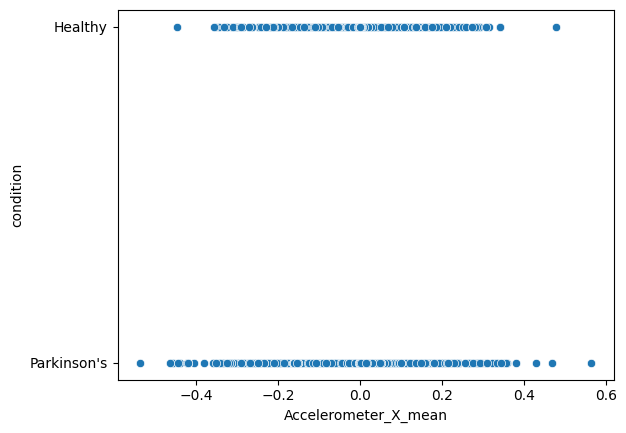

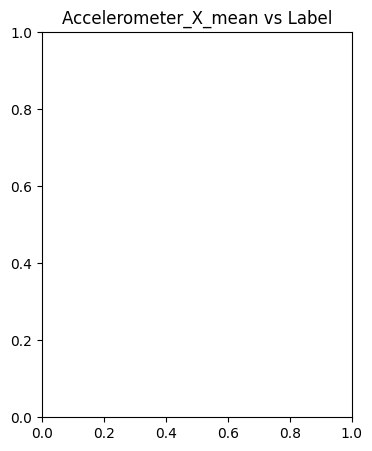

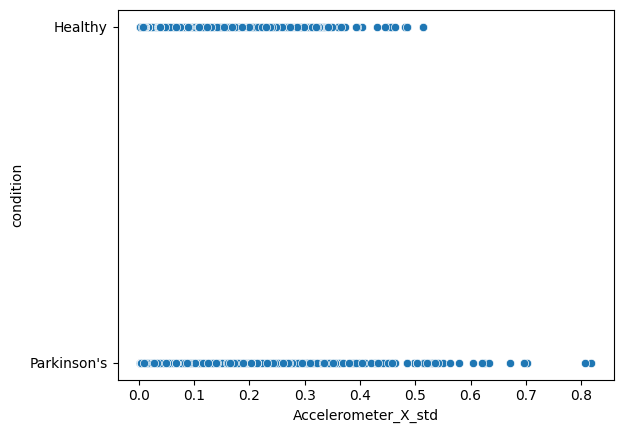

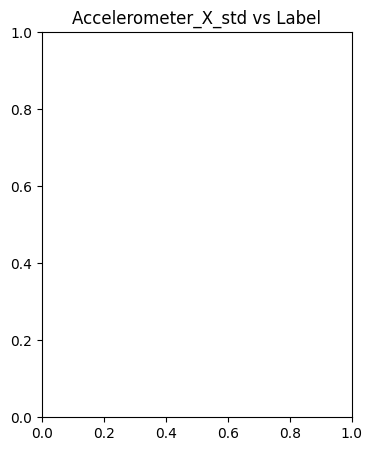

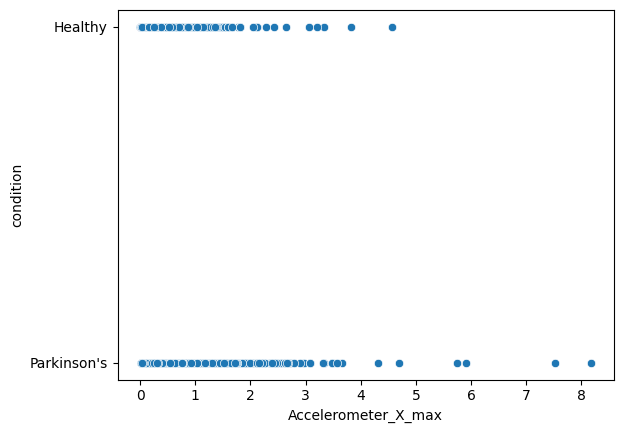

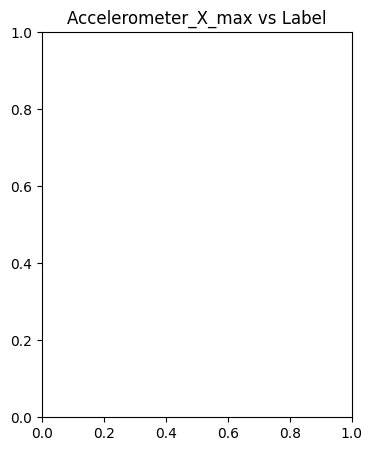

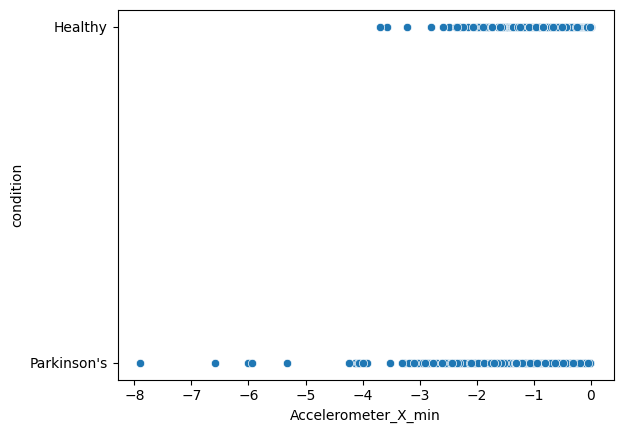

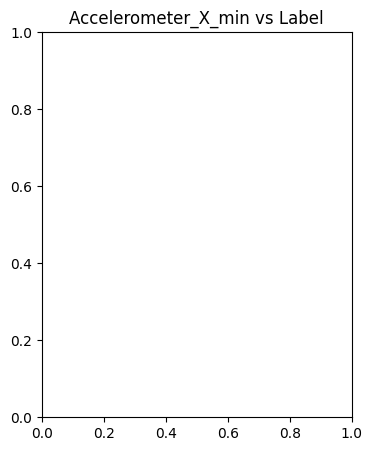

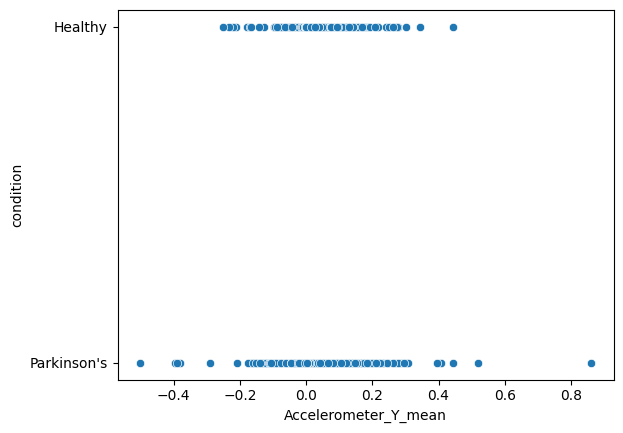

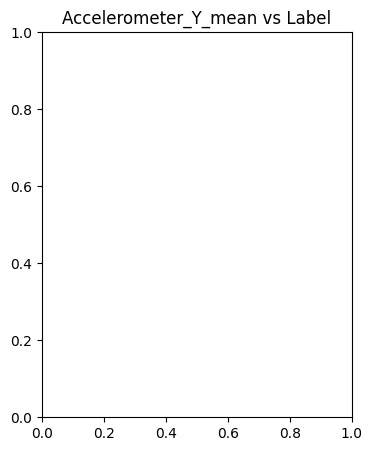

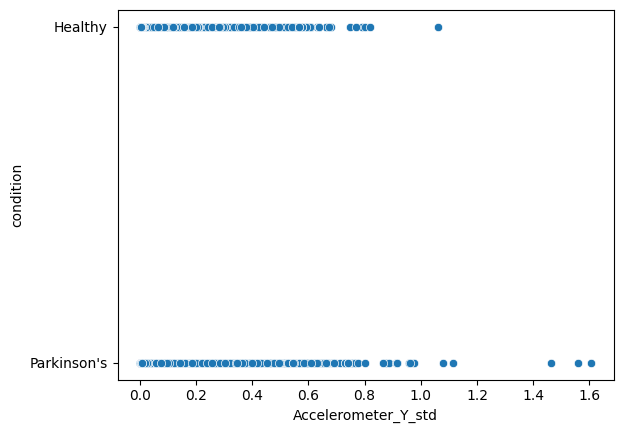

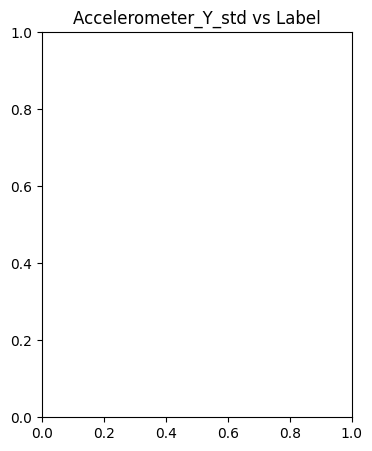

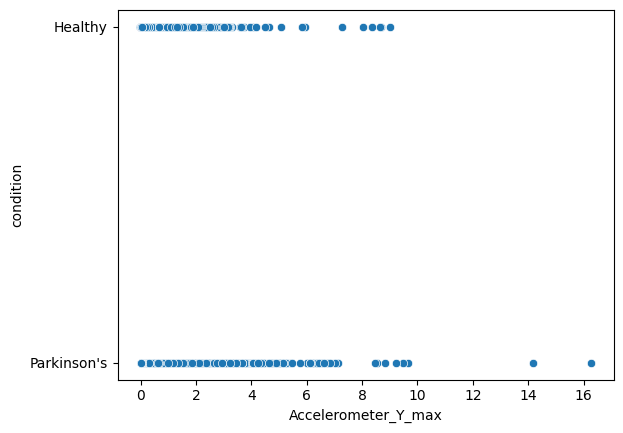

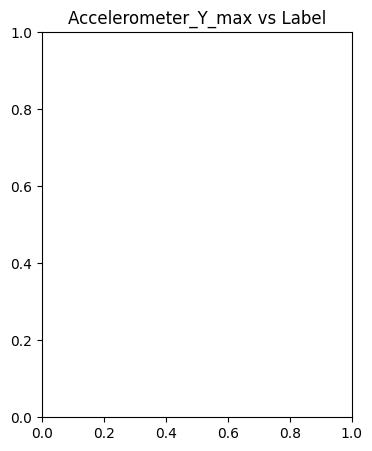

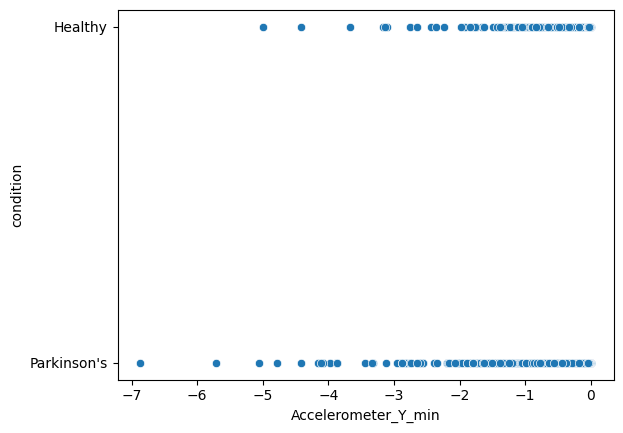

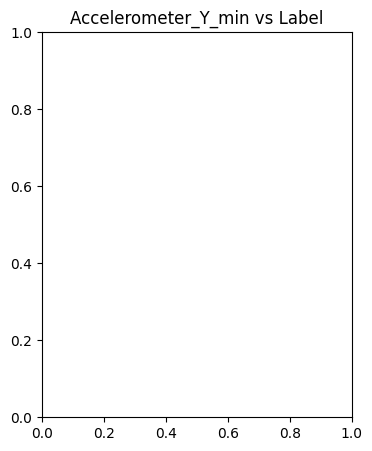

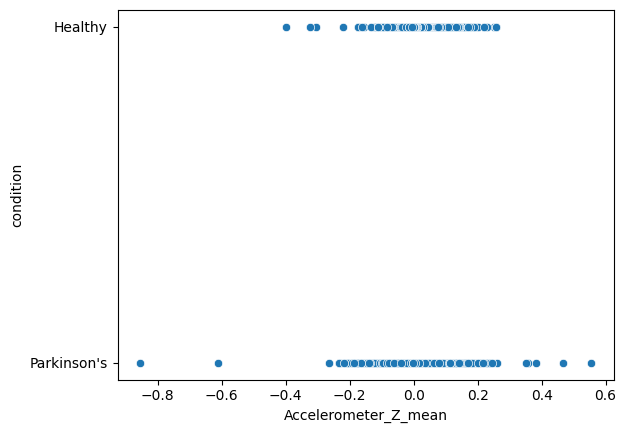

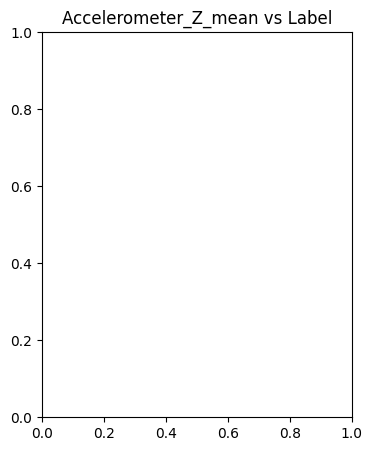

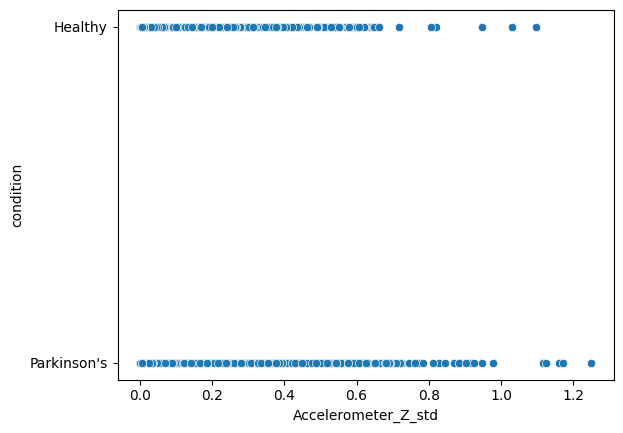

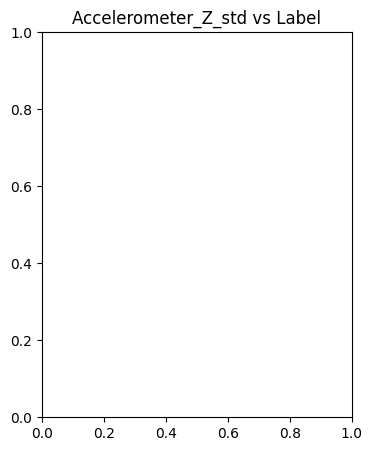

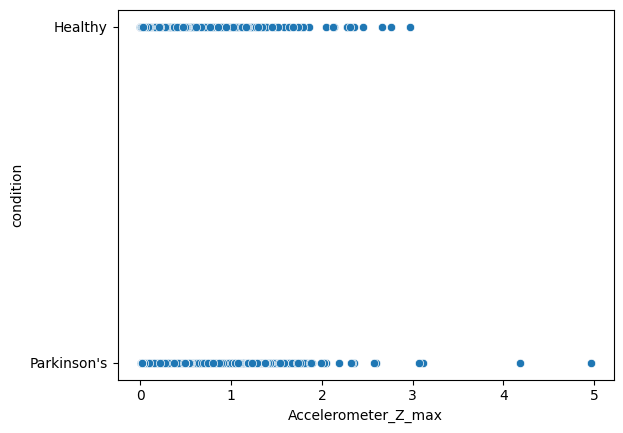

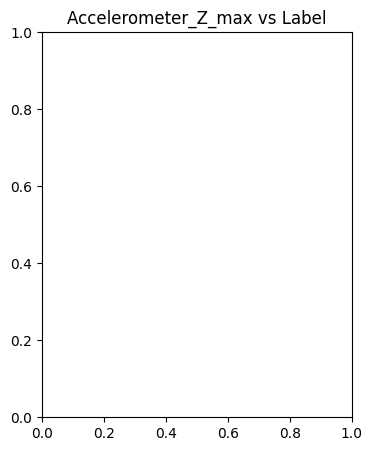

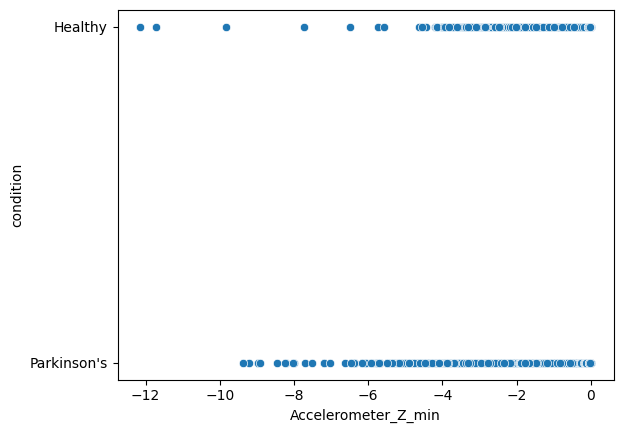

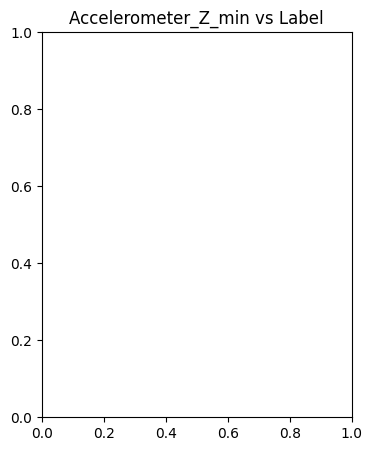

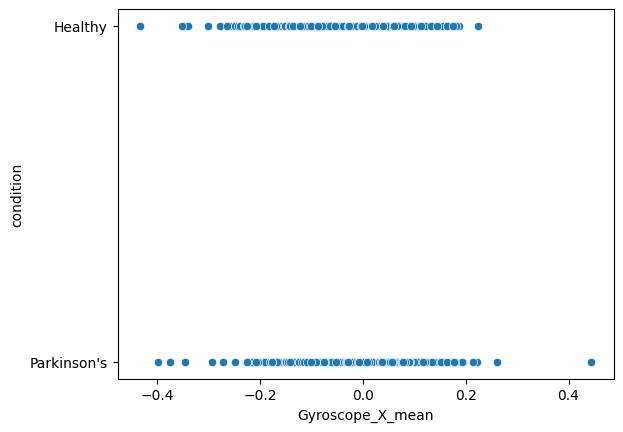

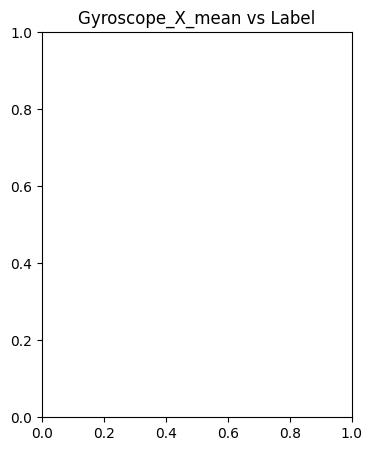

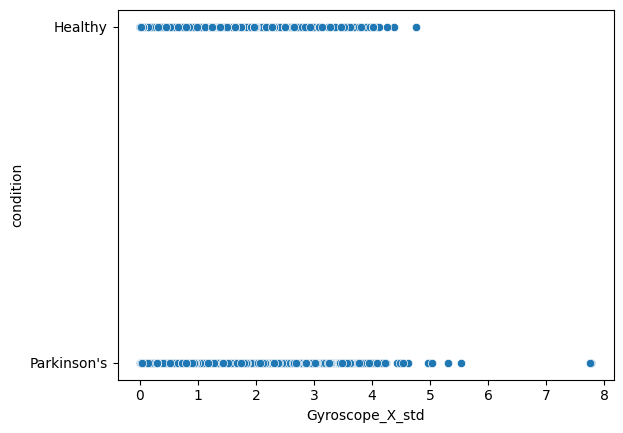

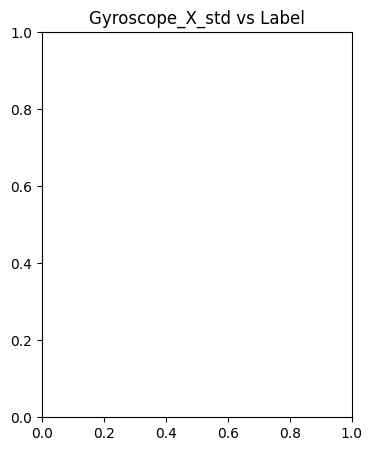

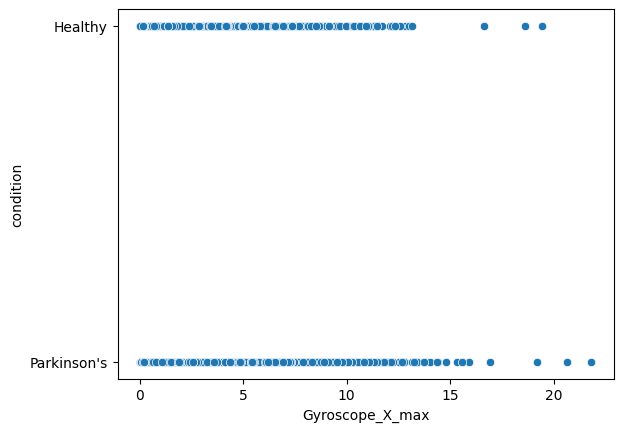

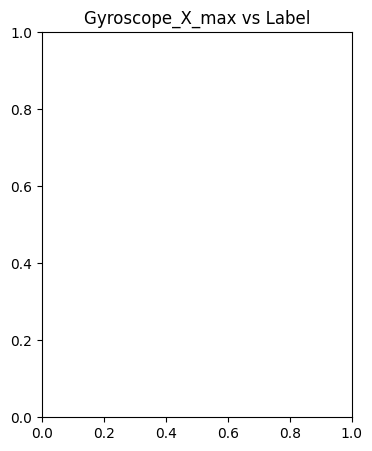

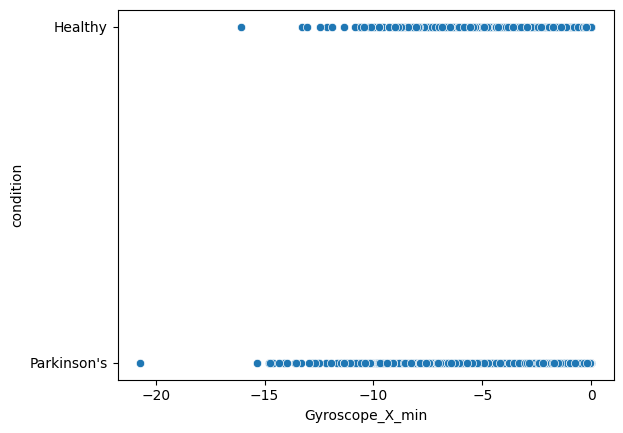

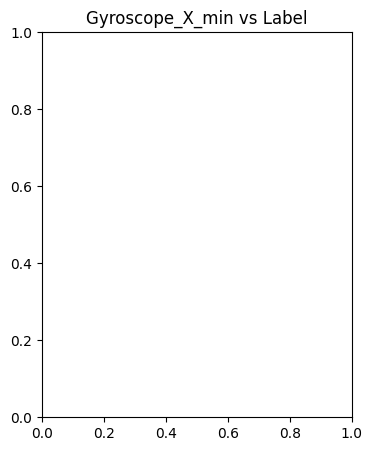

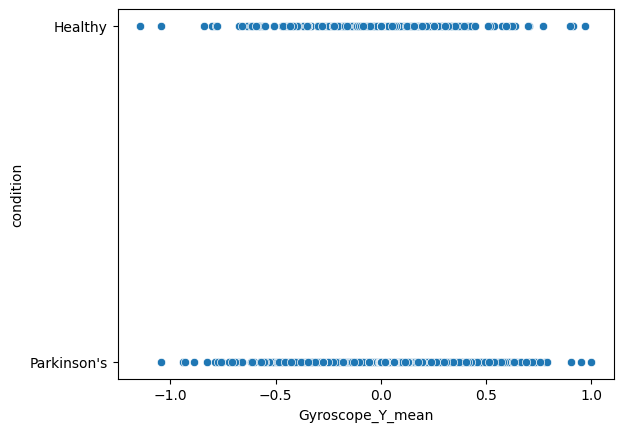

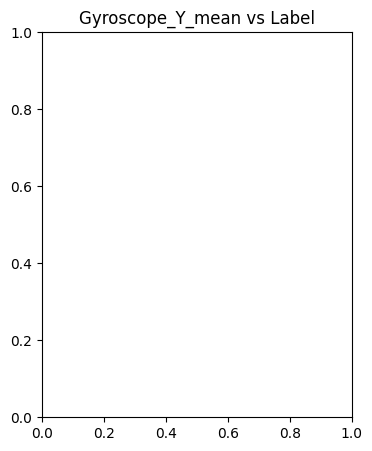

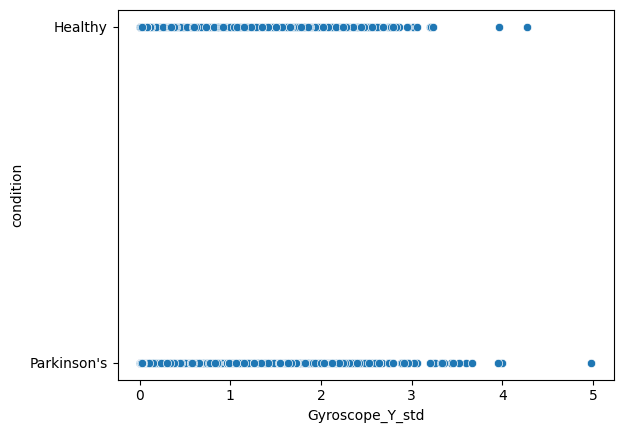

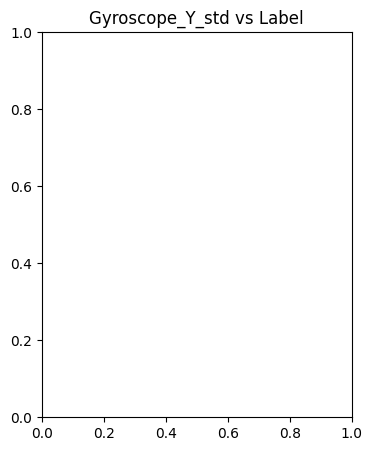

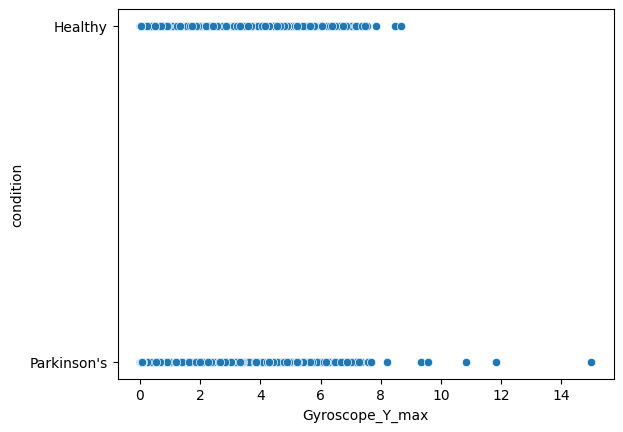

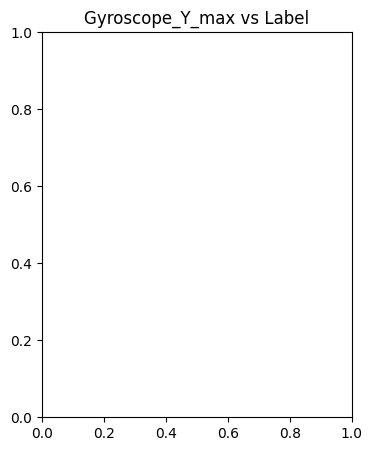

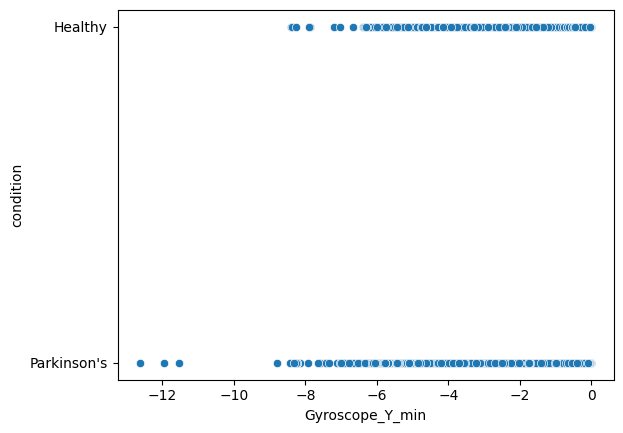

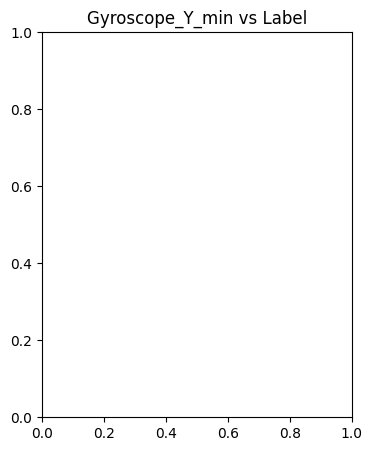

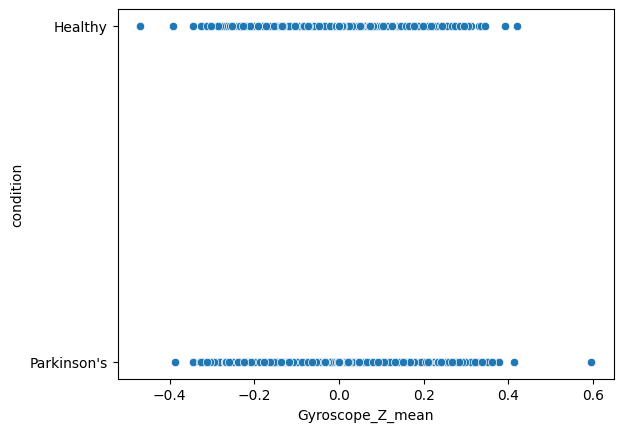

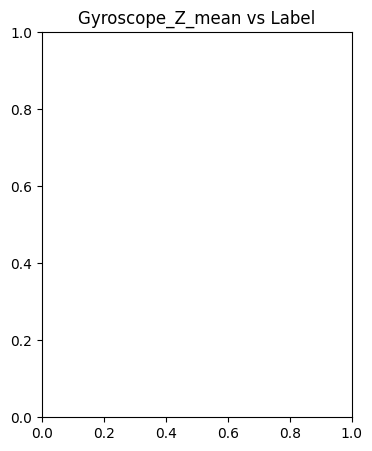

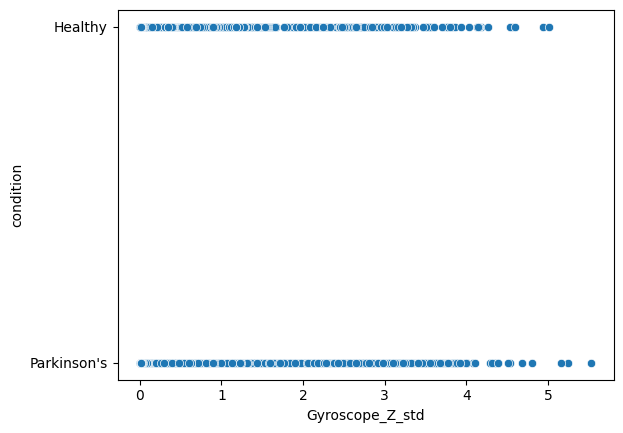

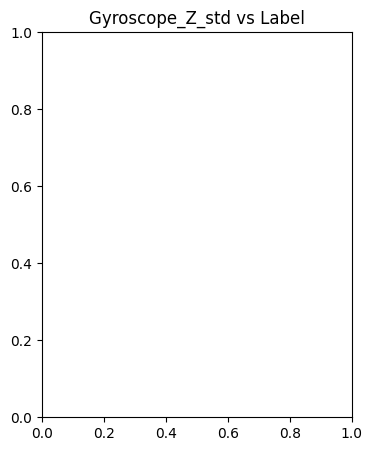

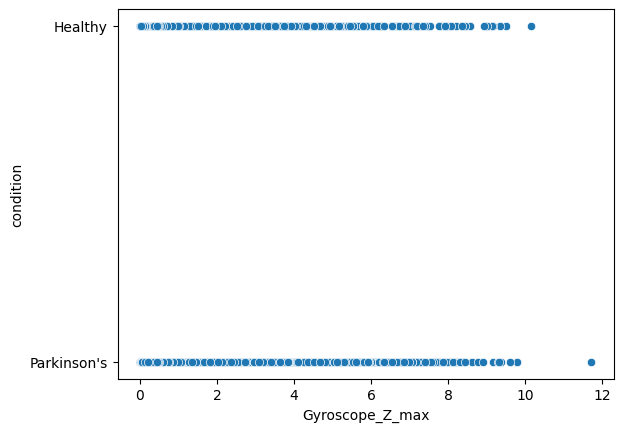

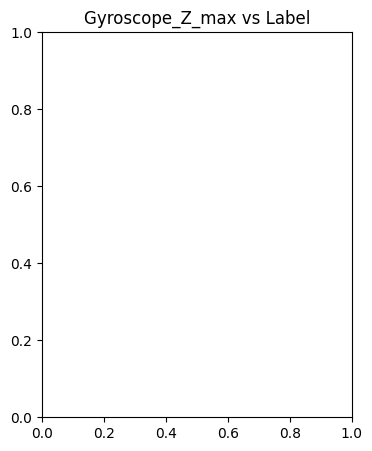

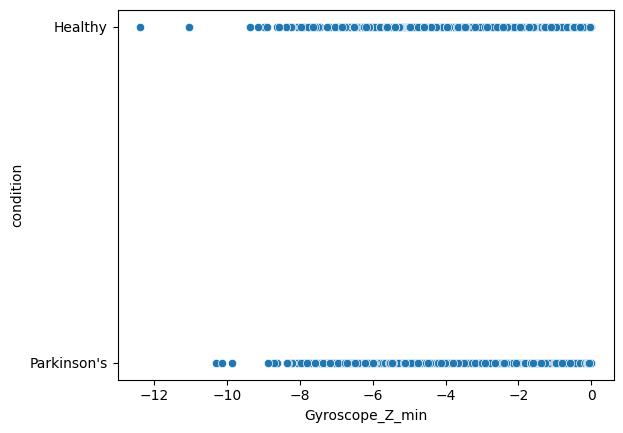

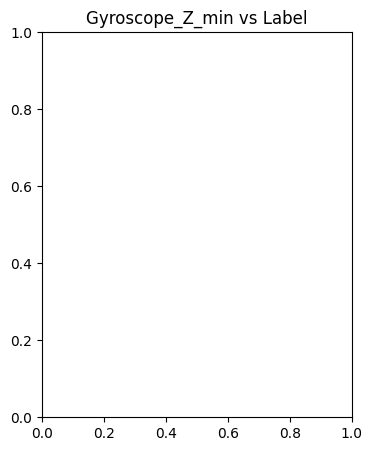

In [35]:

import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    sns.scatterplot(x=merged_df[col], y=merged_df['condition'])
    plt.figure(figsize=(4,5))
    plt.title(f'{col} vs Label')
    plt.show()

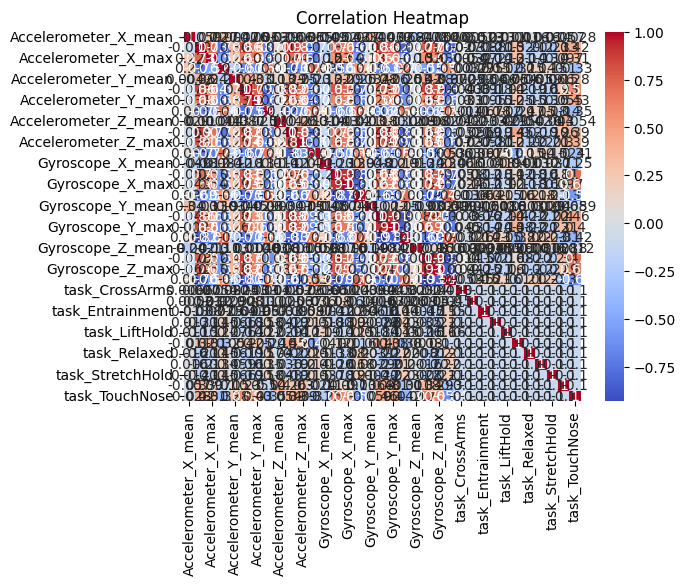

<Figure size 800x600 with 0 Axes>

In [37]:
corr_matrix = merged_df.drop(columns = ["condition", "patient_id", "wrist"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.figure(figsize = (8,6))
plt.show()


In [38]:
#Preprocessing and scaling numerical columns 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])

In [39]:
print(merged_df.columns)

Index(['condition', 'patient_id', 'Accelerometer_X_mean',
       'Accelerometer_X_std', 'Accelerometer_X_max', 'Accelerometer_X_min',
       'Accelerometer_Y_mean', 'Accelerometer_Y_std', 'Accelerometer_Y_max',
       'Accelerometer_Y_min', 'Accelerometer_Z_mean', 'Accelerometer_Z_std',
       'Accelerometer_Z_max', 'Accelerometer_Z_min', 'Gyroscope_X_mean',
       'Gyroscope_X_std', 'Gyroscope_X_max', 'Gyroscope_X_min',
       'Gyroscope_Y_mean', 'Gyroscope_Y_std', 'Gyroscope_Y_max',
       'Gyroscope_Y_min', 'Gyroscope_Z_mean', 'Gyroscope_Z_std',
       'Gyroscope_Z_max', 'Gyroscope_Z_min', 'wrist', 'task_CrossArms',
       'task_DrinkGlas', 'task_Entrainment', 'task_HoldWeight',
       'task_LiftHold', 'task_PointFinger', 'task_Relaxed', 'task_RelaxedTask',
       'task_StretchHold', 'task_TouchIndex', 'task_TouchNose'],
      dtype='object')


In [40]:
#One hot encoding the categorical columns 
cat_cols  = [col for col in merged_df if merged_df[col].dtype == "object"]
print(cat_cols)

['condition', 'wrist']


In [41]:
#Finding unique values
for col in cat_cols:
    print()
    print(merged_df[col].value_counts())
    if col == "task":
        task_series = merged_df[col].value_counts()


condition
Parkinson's    6072
Healthy        1738
Name: count, dtype: int64

wrist
LeftWrist     3905
RightWrist    3905
Name: count, dtype: int64


In [42]:
#Working on the wrist 
merged_df = pd.get_dummies(merged_df, columns = ["wrist"])

In [43]:
#Saving preprocessed file 
merged_df.to_csv("preprocessed_typing.csv", index=False)

In [44]:
merged_df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,...,task_HoldWeight,task_LiftHold,task_PointFinger,task_Relaxed,task_RelaxedTask,task_StretchHold,task_TouchIndex,task_TouchNose,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-0.665711,-1.863480,-1.385773,1.054774,0.148228,-1.635454,...,False,False,False,False,False,False,False,False,True,False
1,Healthy,1,-1.440854,1.455673,-0.550948,-1.017312,0.861733,0.812738,0.347888,-0.760231,...,False,False,False,False,False,False,False,False,False,True
2,Healthy,1,-0.057320,0.000288,0.690811,0.169827,-0.335774,0.253703,0.579272,-2.261057,...,False,False,False,False,False,False,False,False,True,False
3,Healthy,1,-0.417996,1.176585,0.510503,-0.917322,0.049310,1.215156,1.426583,-0.595149,...,False,False,False,False,False,False,False,False,False,True
4,Healthy,1,0.040363,-0.561332,-0.419716,0.227308,-0.140380,-0.571669,-0.498113,0.532107,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10313,Parkinson's,469,0.079142,-0.703760,-0.677144,0.259101,-0.195320,-0.659775,-0.530905,0.619259,...,False,False,False,False,False,True,False,False,False,True
10314,Parkinson's,469,2.342317,1.199528,0.662420,-0.344564,0.929031,1.174975,0.217254,-1.192022,...,False,False,False,False,False,False,True,False,True,False
10315,Parkinson's,469,-2.303851,0.605052,-0.199139,-0.356784,1.537547,0.760961,0.144158,-0.223516,...,False,False,False,False,False,False,True,False,False,True
10316,Parkinson's,469,0.275406,0.242516,-0.098475,-0.068806,-0.315676,1.319913,0.197179,-0.352881,...,False,False,False,False,False,False,False,True,True,False


In [ ]:


#Do feature importance and stuff and make sure 1st 2 pages of app are working from there proceed to 3rd page, which graps audio recording

#Break through tech due today --> damn

#The project with Majoie -- just train on a neural network and evalaute test performance 